<a href="https://colab.research.google.com/github/DiegoAbarza77/Mineria_de_Datos/blob/desarrollo_proyecto/Evaluacion1_Mineria_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Primer entrega de Mineria de datos




Integrantes:
Ignacio Rivera

Diego Abarza





In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns


In [25]:
df = pd.read_csv("/content/Smartphone_Usage_And_Addiction.csv")

In [26]:
df.shape

(7500, 16)

In [27]:
df.head(100)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,TXN00096,U00096,31,Male,10.81,4.47,3.87,3.80,6.08,167,144,11.84,High,No,Moderate,1
96,TXN00097,U00097,29,Male,10.61,2.52,3.05,3.66,8.13,236,158,13.55,High,Yes,Severe,1
97,TXN00098,U00098,23,Male,5.46,4.69,3.69,2.43,5.32,56,159,7.60,Low,Yes,Moderate,1
98,TXN00099,U00099,34,Other,4.94,2.81,1.36,2.54,7.75,218,160,6.93,Low,Yes,NaN,0


In [28]:
df.columns

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')

In [29]:
for feature in df.columns:
  print('Total de valores nulos de', feature, '=', df[feature].isna().
  sum())

Total de valores nulos de transaction_id = 0
Total de valores nulos de user_id = 0
Total de valores nulos de age = 0
Total de valores nulos de gender = 0
Total de valores nulos de daily_screen_time_hours = 0
Total de valores nulos de social_media_hours = 0
Total de valores nulos de gaming_hours = 0
Total de valores nulos de work_study_hours = 0
Total de valores nulos de sleep_hours = 0
Total de valores nulos de notifications_per_day = 0
Total de valores nulos de app_opens_per_day = 0
Total de valores nulos de weekend_screen_time = 0
Total de valores nulos de stress_level = 0
Total de valores nulos de academic_work_impact = 0
Total de valores nulos de addiction_level = 819
Total de valores nulos de addicted_label = 0


                 Valores faltantes  Porcentaje (%)
addiction_level                819           10.92


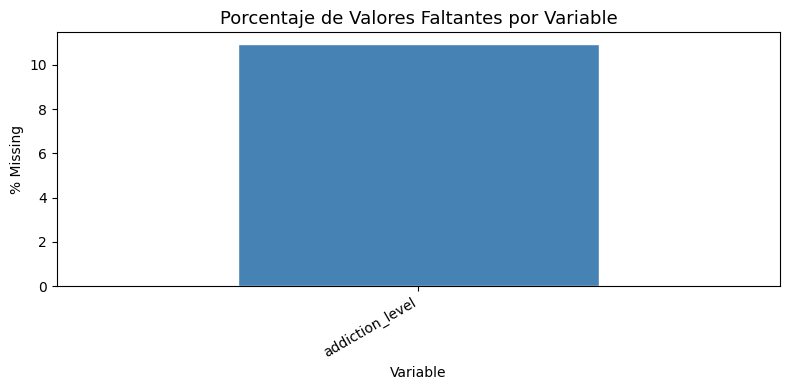

In [30]:
# Conteo y porcentaje de valores faltantes por columna
missing = pd.DataFrame({
    'Valores faltantes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Valores faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)
print(missing)

# Visualización
if not missing.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    missing['Porcentaje (%)'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Porcentaje de Valores Faltantes por Variable', fontsize=13)
    ax.set_ylabel('% Missing')
    ax.set_xlabel('Variable')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

que haremos con los valores nulos?
como es mas del 5% de los valores nulos en este caso

In [31]:
ctext = ['addiction_level']

for columna in ctext:
    mode = df[columna].mode()[0]
    df[columna] = df[columna].fillna(mode)

In [40]:
for feature in df.columns:
  print('Total de valores nulos de', feature, '=', df[feature].isna().
  sum())

Total de valores nulos de transaction_id = 0
Total de valores nulos de user_id = 0
Total de valores nulos de age = 0
Total de valores nulos de gender = 0
Total de valores nulos de daily_screen_time_hours = 0
Total de valores nulos de social_media_hours = 0
Total de valores nulos de gaming_hours = 0
Total de valores nulos de work_study_hours = 0
Total de valores nulos de sleep_hours = 0
Total de valores nulos de notifications_per_day = 0
Total de valores nulos de app_opens_per_day = 0
Total de valores nulos de weekend_screen_time = 0
Total de valores nulos de stress_level = 0
Total de valores nulos de academic_work_impact = 0
Total de valores nulos de addiction_level = 0
Total de valores nulos de addicted_label = 0


In [32]:
print(df.dtypes)

transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object


# Realizaremos un mapeo de datos


'transaction_id'

'user_id'

'age'

'gender'

'daily_screen_time_hours'

'social_media_hours'

'gaming_hours'

'work_study_hours'

'sleep_hours'

'notifications_per_day'

'app_opens_per_day'

'weekend_screen_time'

'stress_level'

'academic_work_impact'

'addiction_level'

'addicted_label'

# Clasificacion de Variables
Categorico Nominal: Categorias sin un orden o jerarquia especifica.
Ejemplo: Region, Comuna, Genero.

Categorico Ordinal: Categorias que siguen un orden logico o escala.
Ejemplo: Nivel educacional (Basica, Media, Superior).

Numerico Discreto: Valores que surgen de un conteo y no admiten decimales.
Ejemplo: Cantidad de personas, Numero de hijos.

Numerico Continuo: Valores que resultan de una medicion y pueden tener decimales infinitos.
Ejemplo: Estatura, Peso, Temperatura.

In [33]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [34]:
print(df.dtypes)

transaction_id              object
user_id                     object
age                          int64
gender                      object
daily_screen_time_hours    float64
social_media_hours         float64
gaming_hours               float64
work_study_hours           float64
sleep_hours                float64
notifications_per_day        int64
app_opens_per_day            int64
weekend_screen_time        float64
stress_level                object
academic_work_impact        object
addiction_level             object
addicted_label               int64
dtype: object


In [51]:
porcentaje_adictos = (df[df['addicted_label'] == 1].shape[0] / df.shape[0]) * 100
print(f"El porcentaje de personas adictas es: {porcentaje_adictos:.2f}%")

El porcentaje de personas adictas es: 70.77%


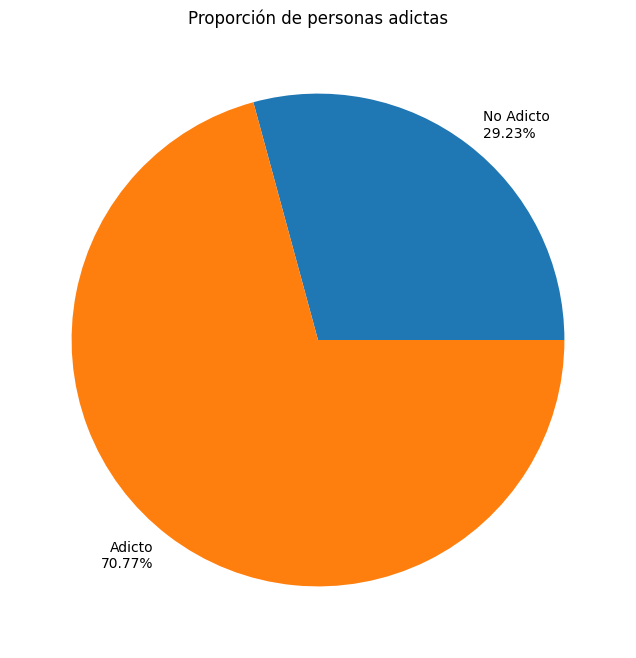

In [52]:
# addiction_counts is still needed for the pie chart data, but percentages for labels will use existing calculation
cuenta_adictos = df.groupby('addicted_label').size()

# Using the previously calculated porcentaje_adictos and deriving no_addicted_percent
porc_no_adictos = 100 - porcentaje_adictos

labels = []
labels.append(f'No Adicto\n{porc_no_adictos:.2f}%')
labels.append(f'Adicto\n{porcentaje_adictos:.2f}%')

plt.figure(figsize=(8, 8))
plt.pie(cuenta_adictos, labels=labels, autopct='')
plt.title('Proporción de personas adictas')
plt.show()

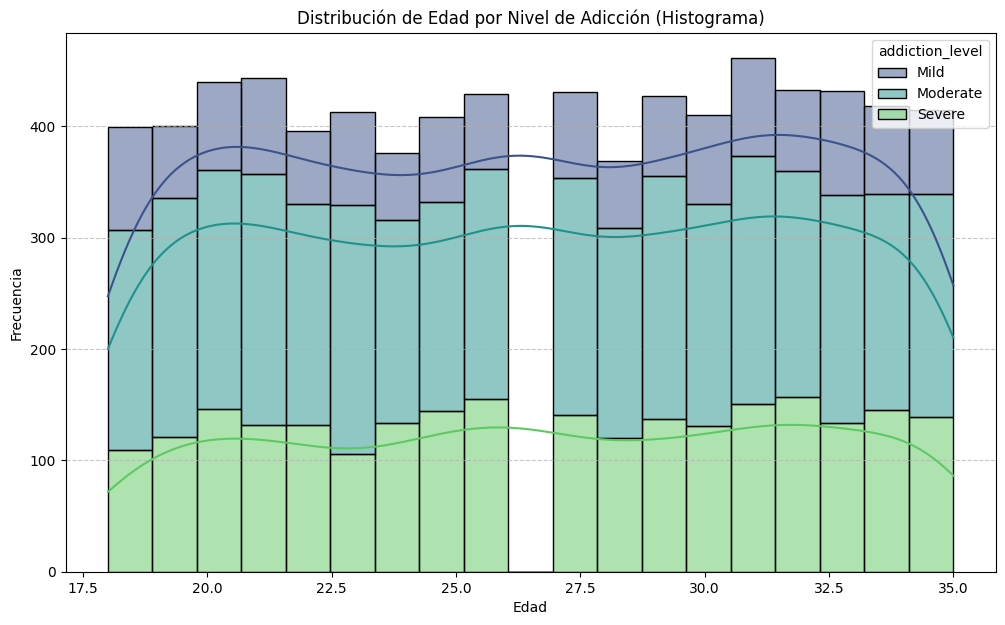

In [49]:
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='age', hue='addiction_level', multiple='stack', kde=True, palette='viridis', hue_order=['Mild', 'Moderate', 'Severe'])
plt.title('Distribución de Edad por Nivel de Adicción (Histograma)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

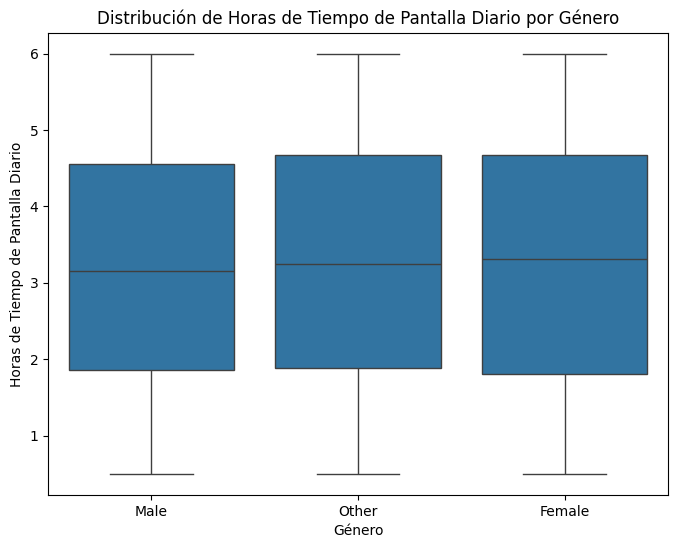

In [35]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='gender', y='work_study_hours', data=df)
plt.title('Distribución de Horas de Tiempo de Pantalla Diario por Género')
plt.xlabel('Género')
plt.ylabel('Horas de Tiempo de Pantalla Diario')
plt.show()

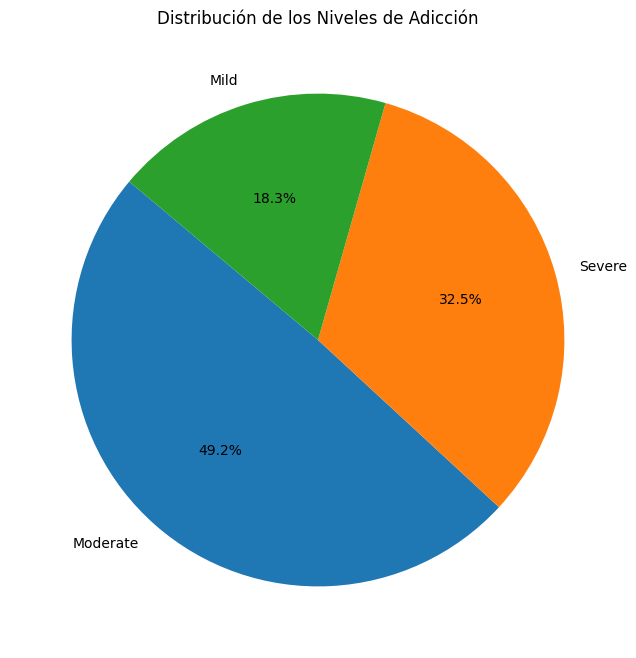

In [54]:
addiction_counts = df['addiction_level'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(addiction_counts, labels=addiction_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribución de los Niveles de Adicción')
plt.ylabel('') # Elimina el "Cantidad de Usuarios" redundante para el gráfico de torta
plt.show()

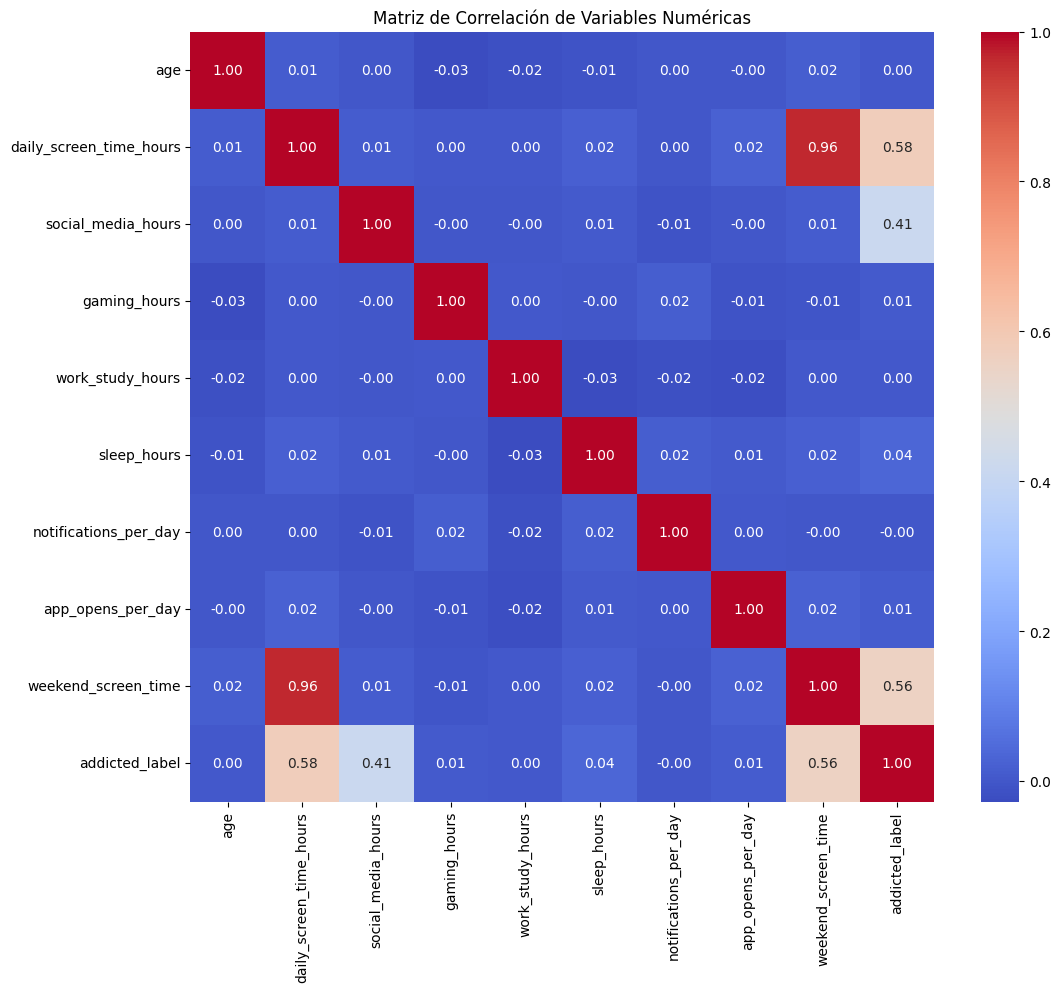

In [41]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[cols_numericas].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

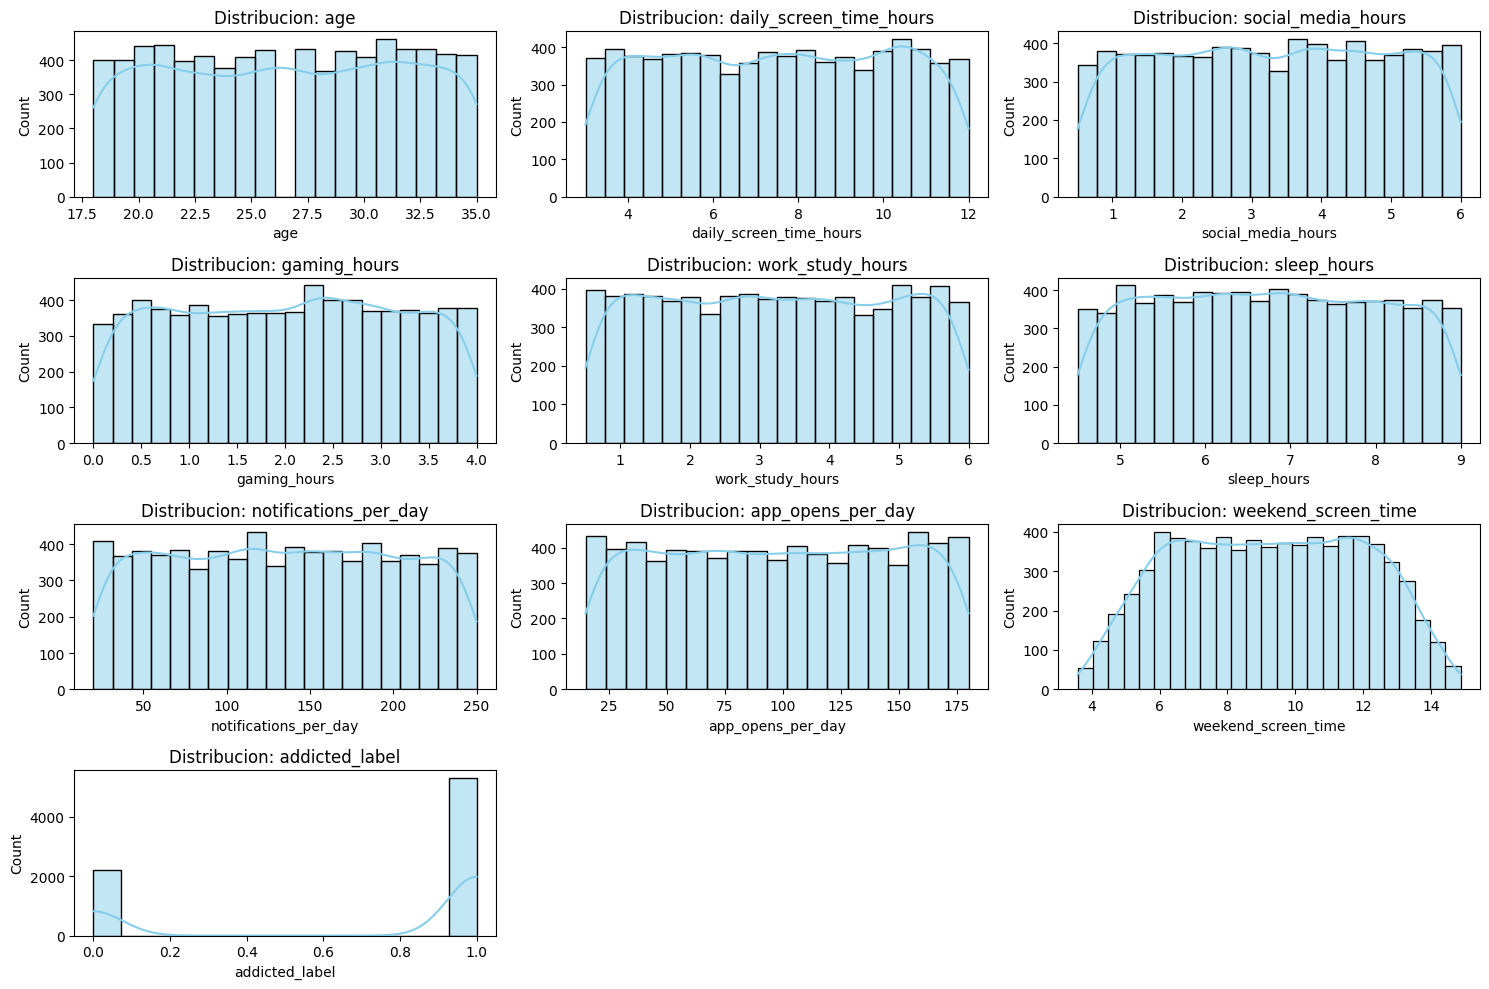

In [38]:

cols_numericas = [
    "age", "daily_screen_time_hours", "social_media_hours", "gaming_hours",
    "work_study_hours", "sleep_hours", "notifications_per_day",
    "app_opens_per_day", "weekend_screen_time", "addicted_label",
]

# Configuracion de graficos
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(4, 3, i)
    # Histograma con curva de densidad
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribucion: {col}')

plt.tight_layout()
plt.show()